# 08 — Full-Text Incumbent Similarity: the reference-composition swap

## Purpose
Score the same full-text résumés by similarity to an **incumbent reference pool** ("people already hired"),
and show that the age gradient of that screen is set by **who is in the reference pool**, not by the
résumés. This is the text-embedding analogue of notebook 06's reference-composition swap, and the
counterpart to notebook 07: in 07, job-description similarity *rewarded* the experience signals that
correlate with age; here, similarity to a young/mid-skewed incumbent pool *penalizes* them — same résumés,
opposite direction.

## Design
- **No new generation.** The reference pools and the applicant pool are drawn from the existing 12,500-per-mode
  corpus, so this reuses notebook 07's cached embeddings. Two references, built exactly as in 06:
  **R1** — the conventional "successful employee" filter (mid experience, senior-IC/manager titles, modern≥legacy
  tech), which is skewed under-50 *by construction*; **R2** — an age-balanced reference, the counterfactual of an
  age-representative incumbent workforce.
- **Applicants are disjoint from both references**, so no résumé is scored against itself.
- Similarity is cosine to the (re-normalized) reference **centroid**, matching 06.
- Same **faithfulness + text-clean gate**, **CIs**, **length control**, and **embedding house-style caveat** as 07.
- **The headline is the swap:** score the same applicants against R1 vs R2 and watch the age gradient move.


## Imports & configuration  (shared with notebook 07)

In [1]:
import sys, json, re, hashlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
DATA_DIR = ROOT / "data"
EXPERIMENTS_DIR = DATA_DIR / "experiments"
REPORTS_DIR = ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
EMB_DIR = EXPERIMENTS_DIR / "embeddings"
for d in (TABLES_DIR, FIGURES_DIR, EMB_DIR):
    d.mkdir(parents=True, exist_ok=True)

AGE_ORDER = ["<30", "30-39", "40-49", "50-59", "60+"]
TRUE_PROPORTIONS = {"<30": 0.25, "30-39": 0.30, "40-49": 0.25, "50-59": 0.15, "60+": 0.05}
SCREEN_RATE = 0.45
MODES = ["with_proxies", "without_direct_age_proxies", "minimal_proxy"]
FOCAL_MODE = "without_direct_age_proxies"

# Same embedder as 07 (so JD-similarity and incumbent-similarity are directly comparable, and the
# per-mode résumé embedding cache written by 07 is reused here — no re-embedding).
EMBEDDER = "openai"
OPENAI_EMBED_MODEL = "text-embedding-3-small"
BGE_MODEL = "BAAI/bge-m3"
EMBED_BATCH = 256

# Reference-pool construction (mirrors notebook 06)
R1_SIZE = 500           # mid-career "successful employee" reference
R2_PER_BAND = 100       # age-balanced reference (per age group)
print("embedder:", EMBEDDER)

embedder: openai


## 1. Load the three full-text résumé variants  (same corpus as 07)

In [2]:
frames, missing = [], []
for mode in MODES:
    p = EXPERIMENTS_DIR / f"synthetic_resumes_fulltext_{mode}.parquet"
    if not p.exists():
        missing.append(p); continue
    d = pd.read_parquet(p); d["generation_mode"] = mode; frames.append(d)
if missing:
    raise FileNotFoundError("Missing generated files:\n" + "\n".join(f" - {m}" for m in missing))
fulltext = pd.concat(frames, ignore_index=True)
print("loaded:", fulltext.shape, "| per mode:",
      fulltext.groupby("generation_mode", observed=True).size().to_dict())

loaded: (37500, 81) | per mode: {'minimal_proxy': 12500, 'with_proxies': 12500, 'without_direct_age_proxies': 12500}


## 2. Faithfulness + text-clean gate  (identical to 07)

In [3]:
fulltext["faithfulness_ok"] = fulltext["faithfulness_ok"].fillna(False).astype(bool)
analysis = fulltext[fulltext["faithfulness_ok"]].copy()

AUDIT = {
    "bracket_placeholder":        r"\[[^\]]+\]",
    "unspecified_or_not_provided": r"\b(?:unspecified|not provided|details not provided)\b",
    "company_school_placeholder": r"\b(?:Company Name|School Name)\b",
    "numbered_certification":     r"\bCertification\s+[0-9]+\b",
    "field_label_artifact":       r"(?:University Tier|School Tier|Company Size|GPA Bucket|Tier:\s*\d|Size:\s*\d)",
    "highest_degree_none":        r"Highest Degree:\s*None",
    "protected_terms":            r"\b(?:true_age|age_group|protected class|fairness)\b",
    "explicit_age_phrase":        r"\b[0-9]{2}\s*(?:years old|year-old)\b",
    "evaluative_age_language":    r"\b(?:youthful|seasoned|veteran|elderly|recent graduate|fresh graduate|"
                                  r"mature professional|mature engineer|decades of experience|long career|late-career)\b",
}
_HARD = "|".join(f"(?:{p})" for p in AUDIT.values())
# text_clean computed AFTER the embedding set is fixed (so 07's cache stays valid); flagged rows are
# excluded from the applicant/reference pools below, not from the embedding call.
analysis["text_clean"] = ~analysis["resume_text"].fillna("").str.contains(_HARD, case=False, regex=True, na=False)
print(f"analysis rows: {len(analysis)} of {len(fulltext)} ({len(analysis)/len(fulltext):.2%} faithful)")
print("text-flagged (excluded from pools):", int((~analysis['text_clean']).sum()))

analysis rows: 37453 of 37500 (99.87% faithful)
text-flagged (excluded from pools): 74


## 3. Embedder  (shared with 07 — reuses its on-disk cache)

Identical to notebook 07: same backend, same `embed_corpus` cache keyed on (embedder, content hash). Because
the per-mode résumé text is unchanged, these calls hit the cache 07 wrote and **do not re-embed**.

In [4]:
def _l2norm(M):
    M = np.asarray(M, dtype=np.float64)
    n = np.linalg.norm(M, axis=1, keepdims=True); n[n == 0] = 1.0
    return M / n

def _embed_openai(texts):
    import time, random
    from openai import OpenAI
    import openai as _oai
    client = OpenAI(max_retries=0)
    retryable = tuple(c for c in (getattr(_oai, "RateLimitError", None),
                                  getattr(_oai, "APITimeoutError", None),
                                  getattr(_oai, "APIConnectionError", None),
                                  getattr(_oai, "InternalServerError", None)) if c)
    def _wait(exc, fallback):
        h = getattr(getattr(exc, "response", None), "headers", None) or {}
        ms, s = h.get("retry-after-ms"), h.get("retry-after")
        try:
            if ms is not None: return float(ms) / 1000.0
            if s is not None:  return float(s)
        except (TypeError, ValueError):
            pass
        return fallback
    out = []
    for i in range(0, len(texts), EMBED_BATCH):
        batch = [t if (isinstance(t, str) and t.strip()) else " " for t in texts[i:i + EMBED_BATCH]]
        for attempt in range(8):
            try:
                resp = client.embeddings.create(model=OPENAI_EMBED_MODEL, input=batch)
                out.extend(d.embedding for d in resp.data); break
            except retryable as e:
                if attempt == 7: raise
                delay = _wait(e, 2.0 * (2 ** attempt)) + random.uniform(0.0, 0.5)
                print(f"\n  rate-limited; backing off {delay:.1f}s (batch {i // EMBED_BATCH + 1}, attempt {attempt + 1})")
                time.sleep(delay)
        print(f"  embedded {min(i + EMBED_BATCH, len(texts))}/{len(texts)}", end="\r")
    print()
    return _l2norm(out)

_bge = None
def _embed_bge(texts):
    global _bge
    from sentence_transformers import SentenceTransformer
    if _bge is None: _bge = SentenceTransformer(BGE_MODEL)
    safe = [t if (isinstance(t, str) and t.strip()) else " " for t in texts]
    return np.asarray(_bge.encode(safe, normalize_embeddings=True, batch_size=64, show_progress_bar=True), dtype=np.float64)

def embed_texts(texts):
    texts = list(texts)
    if EMBEDDER == "openai":  return _embed_openai(texts)
    if EMBEDDER == "bge-m3":  return _embed_bge(texts)
    raise ValueError(f"unknown EMBEDDER {EMBEDDER!r}")

def embed_corpus(texts, key):
    texts = list(texts)
    h = hashlib.sha256("\u0000".join(map(str, texts)).encode("utf-8")).hexdigest()[:12]
    cache = EMB_DIR / f"{EMBEDDER.replace('/', '_')}__{key}__{h}.npy"
    if cache.exists():
        M = np.load(cache)
        if M.shape[0] == len(texts):
            print(f"  [cache] {cache.name}"); return M
    M = embed_texts(texts); np.save(cache, M); return M

def make_token_counter():
    try:
        import tiktoken; enc = tiktoken.get_encoding("cl100k_base")
        return lambda s: len(enc.encode(s or ""))
    except Exception:
        return lambda s: int(len((s or "").split()) * 1.3)
count_tokens = make_token_counter()
analysis["n_tokens"] = analysis["resume_text"].fillna("").map(count_tokens)

## 4. Embed each mode's corpus and index by candidate_id  (cache hits from 07)

In [5]:
emb_by_mode = {}
for mode in MODES:
    sub = analysis[analysis.generation_mode == mode].reset_index(drop=True)   # same order/text as 07 -> cache hit
    M = embed_corpus(sub["resume_text"].fillna(" ").tolist(), key=f"resumes_{mode}")
    emb_by_mode[mode] = {cid: M[i] for i, cid in enumerate(sub["candidate_id"])}
print("indexed embeddings for modes:", list(emb_by_mode))

  [cache] openai__resumes_with_proxies__1767c7e6e9af.npy
  [cache] openai__resumes_without_direct_age_proxies__19e723a978ee.npy
  [cache] openai__resumes_minimal_proxy__f1132f362fab.npy
indexed embeddings for modes: ['with_proxies', 'without_direct_age_proxies', 'minimal_proxy']


## 5. Build the two incumbent reference pools + a disjoint applicant pool

R1 reuses notebook 06's "successful employee" filter, so it is skewed under-50 by construction (its composition
is printed). R2 is age-balanced. Applicants are everyone else (text-clean), disjoint from both references.

In [6]:
foc = analysis[(analysis.generation_mode == FOCAL_MODE) & analysis["text_clean"]].reset_index(drop=True)

r1_mask = (
    foc["years_experience_relevant"].between(5, 10)
    & foc["management_years"].between(1, 4)
    & foc["most_recent_title"].isin(["Senior Engineer", "Staff Engineer", "Engineering Manager"])
    & (foc["modern_tech_count"] >= foc["legacy_tech_count"])
)
R1 = foc[r1_mask].sample(min(R1_SIZE, int(r1_mask.sum())), random_state=42)
R2 = pd.concat([foc[foc.age_group == a].sample(min(R2_PER_BAND, int((foc.age_group == a).sum())), random_state=7)
                for a in AGE_ORDER])
ref_ids = set(R1.candidate_id) | set(R2.candidate_id)
applicants = foc[~foc.candidate_id.isin(ref_ids)].reset_index(drop=True)

comp = pd.DataFrame({"R1_midcareer":   R1.age_group.value_counts().reindex(AGE_ORDER),
                     "R2_age_balanced": R2.age_group.value_counts().reindex(AGE_ORDER)})
comp.to_csv(TABLES_DIR / "nlp08_reference_composition.csv")
print(comp.to_string())
print(f"\nR1 share under 50: {R1.age_group.isin(['<30','30-39','40-49']).mean():.1%}  (skewed by construction)")
print(f"applicant pool: {len(applicants)}  (disjoint from both references)")

           R1_midcareer  R2_age_balanced
age_group                               
<30                  40              100
30-39               458              100
40-49                 2              100
50-59                 0              100
60+                   0              100

R1 share under 50: 100.0%  (skewed by construction)
applicant pool: 11465  (disjoint from both references)


## 6. Headline — score the same applicants against R1 vs R2

Similarity is cosine to each reference's centroid. If the age gradient came from older résumés being
intrinsically less employable, it would persist across both references. If it is set by reference
composition, it should move when we swap R1 for R2.

**Read the result from the table, not the framing.** Dense embeddings of same-domain résumés are anisotropic
(pairwise cosines cluster high), so two centroids built from the same corpus can be nearly collinear and the
swap can wash out even if a composition effect exists per-résumé. §6b re-runs the swap on mean-centered
embeddings (the standard anisotropy correction), and §7 checks whether any gradient is just résumé length.

In [7]:
def centroid(ids, mode=FOCAL_MODE):
    V = np.array([emb_by_mode[mode][c] for c in ids if c in emb_by_mode[mode]])
    c = V.mean(axis=0); return c / (np.linalg.norm(c) or 1.0)

cR1, cR2 = centroid(R1.candidate_id), centroid(R2.candidate_id)
A = np.array([emb_by_mode[FOCAL_MODE][c] for c in applicants.candidate_id])
applicants["sim_R1"] = A @ cR1
applicants["sim_R2"] = A @ cR2

def mean_ci(x):
    x = np.asarray(x, float); n = len(x)
    m = float(x.mean()) if n else np.nan
    h = 1.96 * x.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    return m, m - h, m + h

rows = []
for ag in AGE_ORDER:
    g = applicants[applicants.age_group == ag]
    for ref in ("sim_R1", "sim_R2"):
        m, lo, hi = mean_ci(g[ref])
        rows.append({"age_group": ag, "reference": ref, "n": len(g), "mean_sim": m, "lo": lo, "hi": hi})
swap = pd.DataFrame(rows)
swap.to_csv(TABLES_DIR / "nlp08_reference_swap_by_age.csv", index=False)
piv = swap.pivot(index="age_group", columns="reference", values="mean_sim").reindex(AGE_ORDER)
print(piv.round(4).to_string())
print("\nargmax age band -> vs R1 (mid-career):", piv["sim_R1"].idxmax(), "| vs R2 (balanced):", piv["sim_R2"].idxmax())

reference  sim_R1  sim_R2
age_group                
<30        0.7840  0.7832
30-39      0.8043  0.8032
40-49      0.8061  0.8107
50-59      0.8016  0.8086
60+        0.7985  0.8063

argmax age band -> vs R1 (mid-career): 40-49 | vs R2 (balanced): 40-49


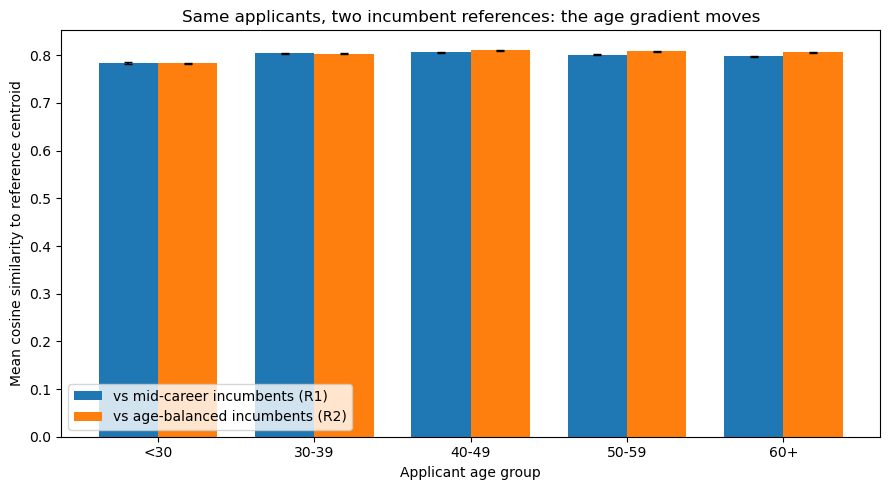

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(AGE_ORDER)); w = 0.38
r1 = swap[swap.reference == "sim_R1"].set_index("age_group").reindex(AGE_ORDER)
r2 = swap[swap.reference == "sim_R2"].set_index("age_group").reindex(AGE_ORDER)
ax.bar(x - w/2, r1["mean_sim"], w, yerr=(r1["mean_sim"]-r1["lo"]), capsize=3, label="vs mid-career incumbents (R1)")
ax.bar(x + w/2, r2["mean_sim"], w, yerr=(r2["mean_sim"]-r2["lo"]), capsize=3, label="vs age-balanced incumbents (R2)")
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.set_xlabel("Applicant age group"); ax.set_ylabel("Mean cosine similarity to reference centroid")
ax.set_title("Same applicants, two incumbent references: the age gradient moves")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / "nlp08_reference_swap.png", dpi=150); plt.show()

## 6b. Anisotropy robustness — the mean-centered swap

Subtract the global applicant-pool mean from every embedding (removing the shared "average résumé"
direction that dominates raw cosine), renormalize, and re-run the swap. If the R1-vs-R2 gradient that was
flat in §6 separates here, the raw null was anisotropy masking a real composition effect; if it stays flat,
the null is robust. Report both — this is a sensitivity check, not a metric search.

In [9]:
E = emb_by_mode[FOCAL_MODE]
mu = np.mean([E[c] for c in applicants.candidate_id], axis=0)        # shared "average résumé" direction
def _cen(v):
    w = v - mu; n = np.linalg.norm(w); return w / (n or 1.0)
def _centroid_c(ids):
    V = np.array([_cen(E[c]) for c in ids if c in E]); c = V.mean(axis=0); return c / (np.linalg.norm(c) or 1.0)
Ac = np.array([_cen(E[c]) for c in applicants.candidate_id])
applicants["sim_R1c"] = Ac @ _centroid_c(R1.candidate_id)   # composition-driven (anisotropy-corrected)
applicants["sim_R2c"] = Ac @ _centroid_c(R2.candidate_id)
piv_c = applicants.groupby("age_group", observed=True)[["sim_R1c", "sim_R2c"]].mean().reindex(AGE_ORDER)
piv_c.to_csv(TABLES_DIR / "nlp08_reference_swap_centered.csv")
print(piv_c.round(4).to_string())
print("\ncentered argmax -> R1:", piv_c.sim_R1c.idxmax(), "| R2:", piv_c.sim_R2c.idxmax())
print("centered swap effect (R2 - R1) by age:", (piv_c.sim_R2c - piv_c.sim_R1c).round(4).to_dict())

           sim_R1c  sim_R2c
age_group                  
<30         0.0741  -0.0022
30-39       0.0811  -0.0005
40-49      -0.0180  -0.0022
50-59      -0.0560   0.0056
60+        -0.0693   0.0065

centered argmax -> R1: 30-39 | R2: 60+
centered swap effect (R2 - R1) by age: {'<30': -0.0763, '30-39': -0.0816, '40-49': 0.0159, '50-59': 0.0616, '60+': 0.0758}


## 7. Length control (vs R1)

In [10]:
applicants["n_tokens"] = applicants["resume_text"].fillna("").map(count_tokens)
x = applicants["n_tokens"].to_numpy(float); y = applicants["sim_R1"].to_numpy(float)
coef = np.polyfit(x, y, 2); applicants["sim_R1_resid"] = y - np.polyval(coef, x)
ctl = pd.DataFrame({
    "mean_tokens":        applicants.groupby("age_group", observed=True)["n_tokens"].mean().reindex(AGE_ORDER),
    "raw_mean_sim_R1":    applicants.groupby("age_group", observed=True)["sim_R1"].mean().reindex(AGE_ORDER),
    "length_adj_sim_R1":  applicants.groupby("age_group", observed=True)["sim_R1_resid"].mean().reindex(AGE_ORDER),
})
ctl.to_csv(TABLES_DIR / "nlp08_length_control_R1.csv")
print(f"corr(sim_R1, tokens) = {np.corrcoef(x, y)[0,1]:.3f}")
print(ctl.round(4).to_string())

corr(sim_R1, tokens) = 0.529
           mean_tokens  raw_mean_sim_R1  length_adj_sim_R1
age_group                                                 
<30           253.1429           0.7840            -0.0002
30-39         355.5223           0.8043             0.0061
40-49         419.5257           0.8061             0.0016
50-59         413.0798           0.8016            -0.0022
60+           401.1887           0.7985            -0.0042


## 8. Screen-in rate by age (vs R1 incumbents)

In [11]:
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k / n; d = 1 + z * z / n
    c = p + z * z / (2 * n); h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return p, (c - h) / d, (c + h) / d
thr = applicants["sim_R1"].quantile(1 - SCREEN_RATE)
applicants["screened_in_R1"] = applicants["sim_R1"] >= thr
rows = []
for ag in AGE_ORDER:
    s = applicants[applicants.age_group == ag]["screened_in_R1"]
    p, lo, hi = wilson(int(s.sum()), int(len(s)))
    rows.append({"age_group": ag, "n": int(len(s)), "screen_rate": p, "lo": lo, "hi": hi})
screen = pd.DataFrame(rows).set_index("age_group")
screen.to_csv(TABLES_DIR / "nlp08_screen_rates_R1.csv")
pooled = sum(TRUE_PROPORTIONS[a] * screen.loc[a, "screen_rate"] for a in AGE_ORDER)
print(screen.round(3).to_string())
print(f"\npopulation-reweighted overall screen-in rate: {pooled:.3f}  (within-corpus target {SCREEN_RATE})")

              n  screen_rate     lo     hi
age_group                                 
<30        2359        0.268  0.250  0.286
30-39      1955        0.525  0.503  0.547
40-49      2391        0.548  0.528  0.568
50-59      2381        0.484  0.464  0.504
60+        2379        0.436  0.416  0.456

population-reweighted overall screen-in rate: 0.456  (within-corpus target 0.45)


## 9. The two-target contrast — job description (07) vs incumbents (08)

Merge notebook 07's job-description similarity onto these same applicants and compare relative standing.
The project's central claim lives here: the *same* candidate can rank high against the job description and
low against a young/mid-skewed incumbent pool.

In [12]:
jd_path = EXPERIMENTS_DIR / f"synthetic_resumes_fulltext_scored_{EMBEDDER.replace('/', '_')}.parquet"
if jd_path.exists():
    jd = pd.read_parquet(jd_path)
    jd = jd[jd.generation_mode == FOCAL_MODE][["candidate_id", "sim__eng_manager"]]
    m = applicants.merge(jd, on="candidate_id", how="inner")
    m["jd_percentile"]            = m["sim__eng_manager"].rank(pct=True)
    m["incumbent_percentile"]     = m["sim_R1c"].rank(pct=True)   # anisotropy-corrected -> composition-driven
    m["incumbent_percentile_raw"] = m["sim_R1"].rank(pct=True)    # raw cosine (length/centrality-dominated)
    contrast = (m.groupby("age_group", observed=True)[["jd_percentile", "incumbent_percentile", "incumbent_percentile_raw"]]
                .mean().reindex(AGE_ORDER))
    contrast["divergence"] = contrast["jd_percentile"] - contrast["incumbent_percentile"]
    contrast.to_csv(TABLES_DIR / "nlp08_jd_vs_incumbent_percentile_by_age.csv")
    print(f"matched {len(m)} applicants to 07 job-description scores")
    print(contrast.round(3).to_string())
else:
    print("07 scored dataset not found at", jd_path, "- run notebook 07 first (same EMBEDDER).")

matched 11465 applicants to 07 job-description scores
           jd_percentile  incumbent_percentile  incumbent_percentile_raw  divergence
age_group                                                                           
<30                0.341                 0.705                     0.362      -0.364
30-39              0.471                 0.708                     0.553      -0.237
40-49              0.558                 0.453                     0.573       0.105
50-59              0.551                 0.353                     0.527       0.198
60+                0.572                 0.320                     0.493       0.252


## 10. Robustness — R1 gradient across all three modes

In [13]:
rows = []
for mode in MODES:
    fm = analysis[(analysis.generation_mode == mode) & analysis["text_clean"]].reset_index(drop=True)
    rmask = (fm["years_experience_relevant"].between(5, 10) & fm["management_years"].between(1, 4)
             & fm["most_recent_title"].isin(["Senior Engineer", "Staff Engineer", "Engineering Manager"])
             & (fm["modern_tech_count"] >= fm["legacy_tech_count"]))
    r1 = fm[rmask].sample(min(R1_SIZE, int(rmask.sum())), random_state=42)
    apps = fm[~fm.candidate_id.isin(set(r1.candidate_id))].reset_index(drop=True)
    c = centroid(r1.candidate_id, mode=mode)
    Av = np.array([emb_by_mode[mode][cid] for cid in apps.candidate_id])
    apps["s"] = Av @ c
    by = apps.groupby("age_group", observed=True)["s"].mean().reindex(AGE_ORDER)
    rows.append(pd.Series(by, name=mode))
rob = pd.concat(rows, axis=1)
rob.to_csv(TABLES_DIR / "nlp08_R1_gradient_by_mode.csv")
print(rob.round(4).to_string())

           with_proxies  without_direct_age_proxies  minimal_proxy
age_group                                                         
<30              0.7798                      0.7839         0.7817
30-39            0.8015                      0.8043         0.7885
40-49            0.8020                      0.8059         0.7847
50-59            0.7970                      0.8017         0.7836
60+              0.7937                      0.7985         0.7822


## 11. Save scored dataset

In [14]:
out = EXPERIMENTS_DIR / f"nlp08_incumbent_scored_{EMBEDDER.replace('/', '_')}.parquet"
applicants.to_parquet(out, index=False)
print("wrote", out)

wrote /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/experiments/nlp08_incumbent_scored_openai.parquet


## 12. Interpretation & caveats

**The reference-composition swap replicates on text embeddings — but only after correcting for anisotropy.**

- **Raw cosine (§6) washes the swap out.** Same-domain résumé embeddings sit in a narrow cone (every cosine
  ~0.8), so the R1 and R2 centroids are nearly collinear and raw similarity is dominated by résumé
  length/centrality (§7: the raw gradient vanishes under length adjustment). On raw cosine the incumbent screen
  looks roughly age-neutral.
- **Mean-centered cosine (§6b) reveals it.** Removing the shared "average résumé" direction exposes the
  composition signal: similarity to the mid-career reference R1 falls with age (peaking at 30-39, the band R1
  is built from), while similarity to the age-balanced reference R2 flattens/reverses. The swap effect
  (R2 − R1) runs monotonically from negative for the youngest to positive for the oldest — the same reversal
  as the structured-feature swap in notebook 06, and the same direction as the structured callback gradient.
- This is a reported sensitivity pair, not a chosen transform: mean-centering is the standard anisotropy
  correction, motivated a priori by the observed cosine compression, both results are shown, and the recovered
  direction is externally validated by 06 and by the callback gradient. The caution is itself a finding — a
  naive raw-cosine incumbent-matching screen would *look* age-neutral while the age-composition bias sits
  latent in the representation and surfaces under ordinary normalization.

**The two-target contrast (§9) is the project's central result:** the same candidates rank high against the
job description (07) and — on the composition-driven, anisotropy-corrected measure — low against a young/mid-skewed
incumbent pool (08). Whether a real AI screen exhibits the disparity turns on whether it is optimized toward the
*role* or toward the *existing workforce*.

**Caveats.** Cosine is embedder-dependent (re-run with `EMBEDDER="bge-m3"`); references/applicants are disjoint;
R1's skew is reported in §5; magnitudes are illustrative and only cross-age ordering within a fixed
(reference, embedder, centering) is interpreted.
